In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [247]:
Q_ANGLE = 0.001
Q_BIAS = 0.00001
R_MEASURE = 0.03
ACCEL_REJECTION_GAIN = 10000.0

In [248]:
def run_angle_kalman_filter(
    accel_angle_deg,
    gyro_rate_dps,
    dt_s,
    accel_magnitude_g,
    accel_rejection_gain,
    q_angle=Q_ANGLE,
    q_bias=Q_BIAS,
    r_measure=R_MEASURE
):
    """
    Two-state Kalman filter.

    State:
        x[0] = angle in degrees
        x[1] = gyro bias in degrees per second

    Input:
        gyroscope angular rate

    Measurement:
        accelerometer-derived angle
    """

    num_samples = len(accel_angle_deg)

    angle_estimate = np.zeros(num_samples)
    bias_estimate = np.zeros(num_samples)

    # Initial state
    x = np.array([
        accel_angle_deg.iloc[0],
        0.0
    ])

    # Initial state covariance
    P = np.eye(2)

    # Accelerometer measures angle, but not gyro bias
    H = np.array([
        [1.0, 0.0]
    ])

    I = np.eye(2)

    angle_estimate[0] = x[0]
    bias_estimate[0] = x[1]

    r_history = np.zeros(num_samples)
    kalman_gain_history = np.zeros(num_samples)

    r_history[0] = r_measure

    for k in range(1, num_samples):
        dt = dt_s.iloc[k]
        gyro_rate = gyro_rate_dps.iloc[k]
        accel_angle = accel_angle_deg.iloc[k]
        
        # Adaptive R based on non-g accelerometer measurements
        accel_mag = float(accel_magnitude_g.iloc[k])
        accel_deviation = abs(accel_mag - 1.0)
        r_current = r_measure * (
            1.0 + accel_rejection_gain * accel_deviation**2
        )

        # --------------------------------------------------
        # 1. Build the state-transition matrix A
        #
        # State model:
        # angle_new = angle_old + dt * (gyro_rate - bias_old)
        # bias_new  = bias_old
        # --------------------------------------------------
        A = np.array([
            [1.0, -dt],
            [0.0, 1.0]
        ])

        # --------------------------------------------------
        # 2. Build the gyro-input matrix B
        # --------------------------------------------------
        B = np.array([
            dt,
            0
        ])

        # --------------------------------------------------
        # 3. Build the process-noise covariance Q
        # --------------------------------------------------
        Q = np.array([
            [q_angle * dt, 0.0],
            [0.0, q_bias * dt]
        ])

        # ==================================================
        # PREDICTION
        # ==================================================

        # 4. Predict the state
        x_pred = A @ x + B * gyro_rate

        # 5. Predict the covariance
        P_pred = A @ P @ A.T + Q

        # ==================================================
        # MEASUREMENT UPDATE
        # ==================================================

        # 6. Compute predicted accelerometer measurement
        predicted_measurement = (H @ x_pred).item()

        # 7. Compute innovation
        innovation = accel_angle - predicted_measurement

        # 8. Compute innovation variance
        S = (H @ P_pred @ H.T).item() + r_current

        # 9. Compute Kalman gain
        K = P_pred @ H.T / S

        # 10. Correct the predicted state
        x = x_pred + K[:, 0] * innovation

        # 11. Correct the covariance
        P = (I - K @ H) @ P_pred

        angle_estimate[k] = x[0]
        bias_estimate[k] = x[1]

        r_history[k] = r_current
        kalman_gain_history[k] = K[0, 0]

    return (
        angle_estimate,
        bias_estimate,
        r_history,
        kalman_gain_history
    )

In [249]:
def process_imu_data(
    filepath,
    alpha=0.95,
    max_rows=None,
    accel_rejection_gain=ACCEL_REJECTION_GAIN
):
    """
    Load IMU data and calculate accelerometer-only, gyro-only,
    and complementary-filter roll and pitch estimates.
    """

    df = pd.read_csv(filepath)

    if max_rows is not None:
        df = df.iloc[:max_rows].copy()

    # Start time at zero
    df["time_s"] = (
        df["timestamp_ms"] - df["timestamp_ms"].iloc[0]
    ) / 1000.0

    # Time elapsed since previous sample
    dt = np.diff(
        df["time_s"],
        prepend=df["time_s"].iloc[0]
    )

    df["dt_s"] = dt

    # Accelerometer-only orientation
    df["roll_acc_deg"] = np.degrees(
        np.arctan2(
            df["ay_calibrated_g"],
            df["az_calibrated_g"]
        )
    )

    df["pitch_acc_deg"] = np.degrees(
        np.arctan2(
            -df["ax_calibrated_g"],
            np.sqrt(
                df["ay_calibrated_g"]**2
                + df["az_calibrated_g"]**2
            )
        )
    )

    df["accel_mag_g"] = np.sqrt(
        df["ax_calibrated_g"]**2
        + df["ay_calibrated_g"]**2
        + df["az_calibrated_g"]**2
    )

    # Gyroscope-only orientation
    df["roll_gyro_deg"] = (
        df["roll_acc_deg"].iloc[0]
        + np.cumsum(df["gx_dps"] * df["dt_s"])
    )

    df["pitch_gyro_deg"] = (
        df["pitch_acc_deg"].iloc[0]
        + np.cumsum(df["gy_dps"] * df["dt_s"])
    )

    # Complementary-filter orientation
    roll_comp = np.zeros(len(df))
    pitch_comp = np.zeros(len(df))

    roll_comp[0] = df["roll_acc_deg"].iloc[0]
    pitch_comp[0] = df["pitch_acc_deg"].iloc[0]

    for k in range(1, len(df)):
        roll_prediction = (
            roll_comp[k - 1]
            + df["gx_dps"].iloc[k] * df["dt_s"].iloc[k]
        )

        pitch_prediction = (
            pitch_comp[k - 1]
            + df["gy_dps"].iloc[k] * df["dt_s"].iloc[k]
        )

        roll_comp[k] = (
            alpha * roll_prediction
            + (1 - alpha) * df["roll_acc_deg"].iloc[k]
        )

        pitch_comp[k] = (
            alpha * pitch_prediction
            + (1 - alpha) * df["pitch_acc_deg"].iloc[k]
        )

    df["roll_comp_deg"] = roll_comp
    df["pitch_comp_deg"] = pitch_comp

    # Kalman-filter roll
    roll_kf_fixed, roll_bias_fixed, _, _ = run_angle_kalman_filter(
        accel_angle_deg=df["roll_acc_deg"],
        gyro_rate_dps=df["gx_dps"],
        dt_s=df["dt_s"],
        accel_magnitude_g=df["accel_mag_g"],
        accel_rejection_gain=0.0
    )

    # Adaptive gain
    roll_kf_adaptive, roll_bias_adaptive, roll_r, roll_gain = run_angle_kalman_filter(
        accel_angle_deg=df["roll_acc_deg"],
        gyro_rate_dps=df["gx_dps"],
        dt_s=df["dt_s"],
        accel_magnitude_g=df["accel_mag_g"],
        accel_rejection_gain=accel_rejection_gain
    )

    # Kalman-filter pitch
    pitch_kf_fixed, pitch_bias_fixed, _, _ = run_angle_kalman_filter(
        accel_angle_deg=df["pitch_acc_deg"],
        gyro_rate_dps=df["gy_dps"],
        dt_s=df["dt_s"],
        accel_magnitude_g=df["accel_mag_g"],
        accel_rejection_gain=0.0
    )

    df["roll_kf_fixed_deg"] = roll_kf_fixed
    df["roll_kf_adaptive_deg"] = roll_kf_adaptive

    df["roll_bias_fixed_dps"] = roll_bias_fixed
    df["roll_bias_adaptive_dps"] = roll_bias_adaptive

    df["roll_r_kf"] = roll_r
    df["roll_gain_kf"] = roll_gain

    # Adaptive gain
    pitch_kf_adaptive, pitch_bias_adaptive, pitch_r, pitch_gain = run_angle_kalman_filter(
        accel_angle_deg=df["pitch_acc_deg"],
        gyro_rate_dps=df["gy_dps"],
        dt_s=df["dt_s"],
        accel_magnitude_g=df["accel_mag_g"],
        accel_rejection_gain=accel_rejection_gain
    )

    df["pitch_kf_fixed_deg"] = pitch_kf_fixed
    df["pitch_kf_adaptive_deg"] = pitch_kf_adaptive

    df["pitch_bias_fixed_dps"] = pitch_bias_fixed
    df["pitch_bias_adaptive_dps"] = pitch_bias_adaptive

    df["pitch_r_kf"] = pitch_r
    df["pitch_gain_kf"] = pitch_gain
    return df

In [250]:
def plot_kalman_bias_estimates(df, experiment_name, skip_seconds=0.0):
    plot_df = df.loc[df["time_s"] >= skip_seconds]

    plt.figure(figsize=(12, 5))

    plt.plot(
        plot_df["time_s"],
        plot_df["roll_bias_fixed_dps"],
        label="Fixed-R gx bias"
    )

    plt.plot(
        plot_df["time_s"],
        plot_df["roll_bias_adaptive_dps"],
        label="Adaptive-R gx bias",
        linestyle="--"
    )

    plt.plot(
        plot_df["time_s"],
        plot_df["pitch_bias_fixed_dps"],
        label="Fixed-R gy bias"
    )

    plt.plot(
        plot_df["time_s"],
        plot_df["pitch_bias_adaptive_dps"],
        label="Adaptive-R gy bias",
        linestyle="--"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Gyroscope bias (degrees/s)")
    plt.title(f"{experiment_name}: Kalman Gyroscope Bias Estimates")
    plt.legend()
    plt.grid()
    plt.show()

In [251]:
static_df = process_imu_data(
    "Roll Pitch/Roll Pitch Data.csv",
    alpha=0.95,
    max_rows=8001
)

shake_df = process_imu_data(
    "Roll Pitch/Shake Data.csv",
    alpha=0.95
)

hold_df = process_imu_data(
    "Roll Pitch/Long Hold.csv",
    alpha=0.95
)

Static Orientation Test: IMU is rotated to various orientations and held

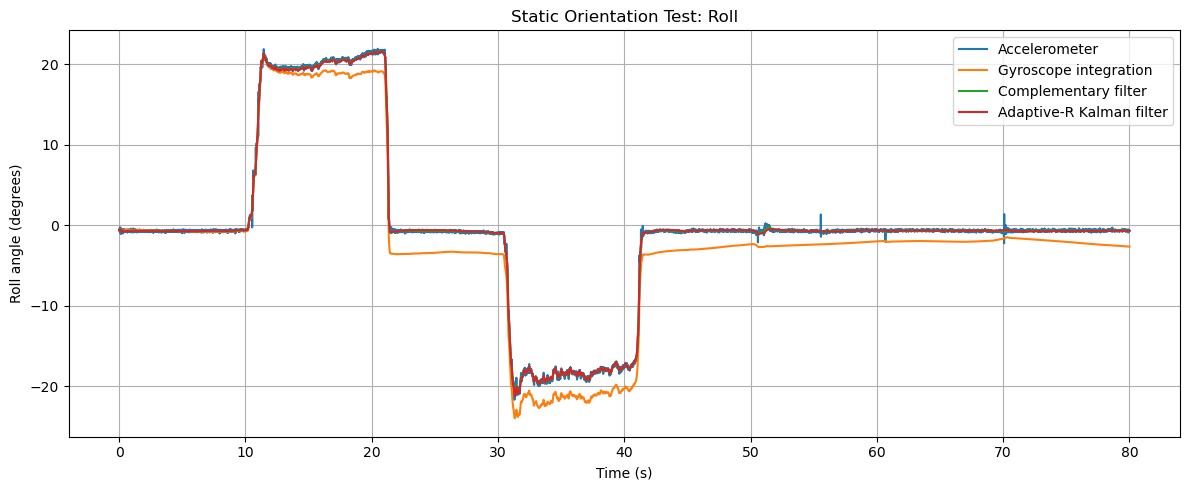

In [252]:
plt.figure(figsize=(12, 5))

plt.plot(
    static_df["time_s"],
    static_df["roll_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    static_df["time_s"],
    static_df["roll_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    static_df["time_s"],
    static_df["roll_comp_deg"],
    label="Complementary filter"
)

plt.plot(
    static_df["time_s"],
    static_df["roll_kf_adaptive_deg"],
    label="Adaptive-R Kalman filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Roll angle (degrees)")
plt.title("Static Orientation Test: Roll")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

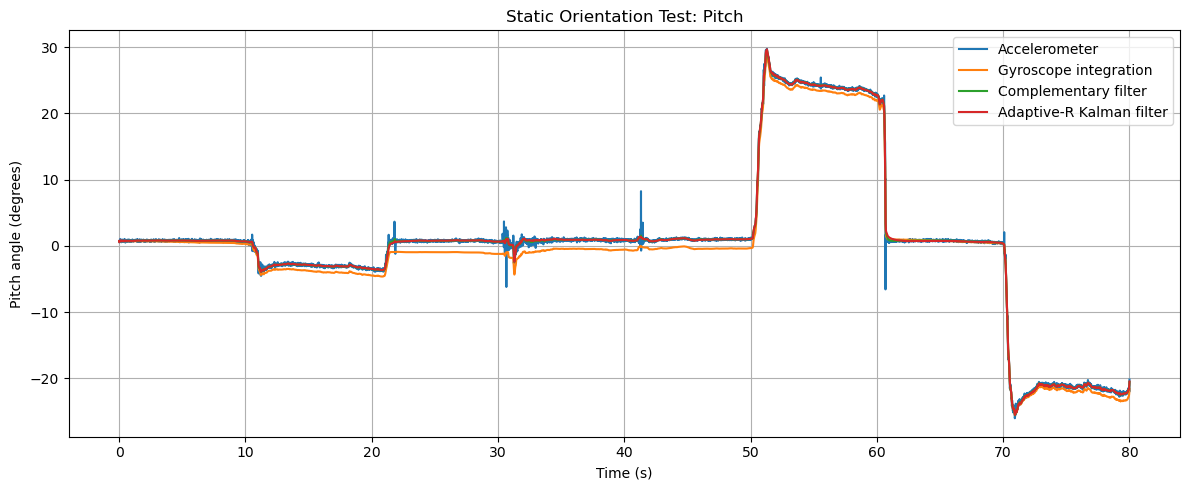

In [253]:

plt.figure(figsize=(12, 5))

plt.plot(
    static_df["time_s"],
    static_df["pitch_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    static_df["time_s"],
    static_df["pitch_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    static_df["time_s"],
    static_df["pitch_comp_deg"],
    label="Complementary filter"
)

plt.plot(
    static_df["time_s"],
    static_df["pitch_kf_adaptive_deg"],
    label="Adaptive-R Kalman filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Pitch angle (degrees)")
plt.title("Static Orientation Test: Pitch")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Long Hold Test: exposes the gyro's weakness with bias accumulating over time

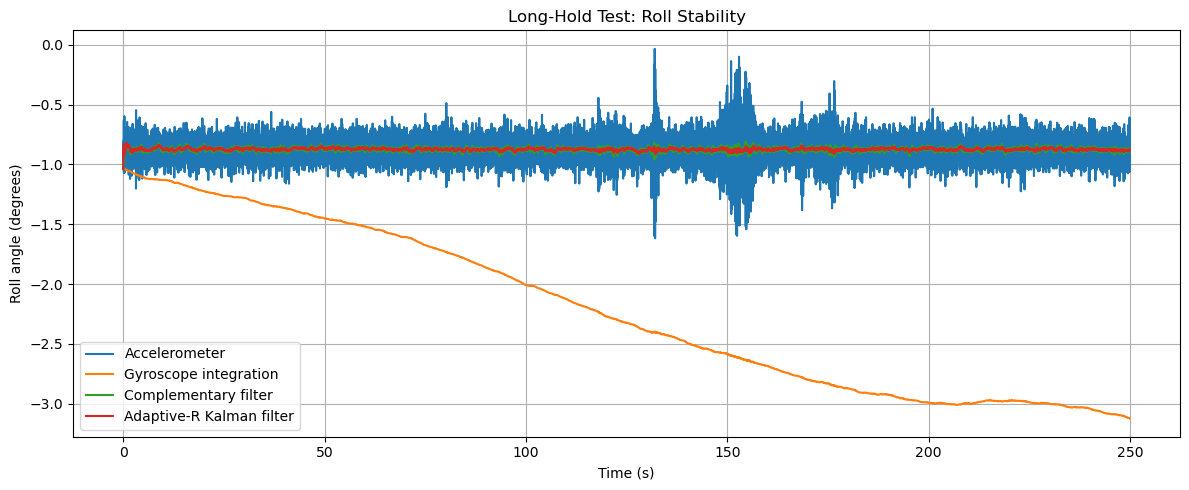

In [254]:
plt.figure(figsize=(12, 5))

plt.plot(
    hold_df["time_s"],
    hold_df["roll_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    hold_df["time_s"],
    hold_df["roll_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    hold_df["time_s"],
    hold_df["roll_comp_deg"],
    label="Complementary filter"
)

plt.plot(
    hold_df["time_s"],
    hold_df["roll_kf_adaptive_deg"],
    label="Adaptive-R Kalman filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Roll angle (degrees)")
plt.title("Long-Hold Test: Roll Stability")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

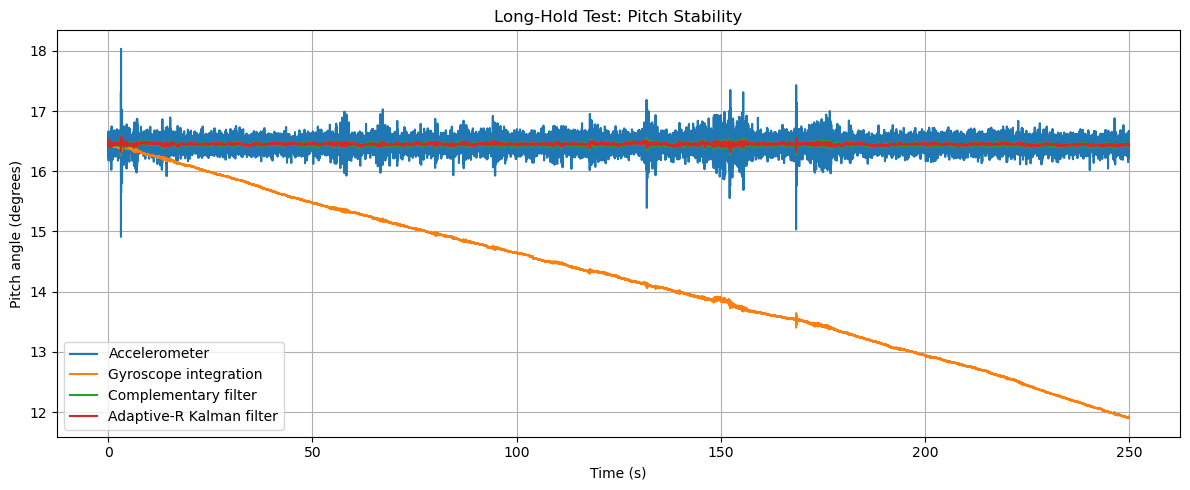

In [255]:

plt.figure(figsize=(12, 5))

plt.plot(
    hold_df["time_s"],
    hold_df["pitch_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    hold_df["time_s"],
    hold_df["pitch_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    hold_df["time_s"],
    hold_df["pitch_comp_deg"],
    label="Complementary filter"
)

plt.plot(
    hold_df["time_s"],
    hold_df["pitch_kf_adaptive_deg"],
    label="Adaptive-R Kalman filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Pitch angle (degrees)")
plt.title("Long-Hold Test: Pitch Stability")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [256]:
# Finding mean angular velocity to compare with bias estimate
skip_seconds = 5.0

bias_df = hold_df.loc[
    hold_df["time_s"] >= skip_seconds
]

gx_mean_dps = bias_df["gx_dps"].mean()
gy_mean_dps = bias_df["gy_dps"].mean()

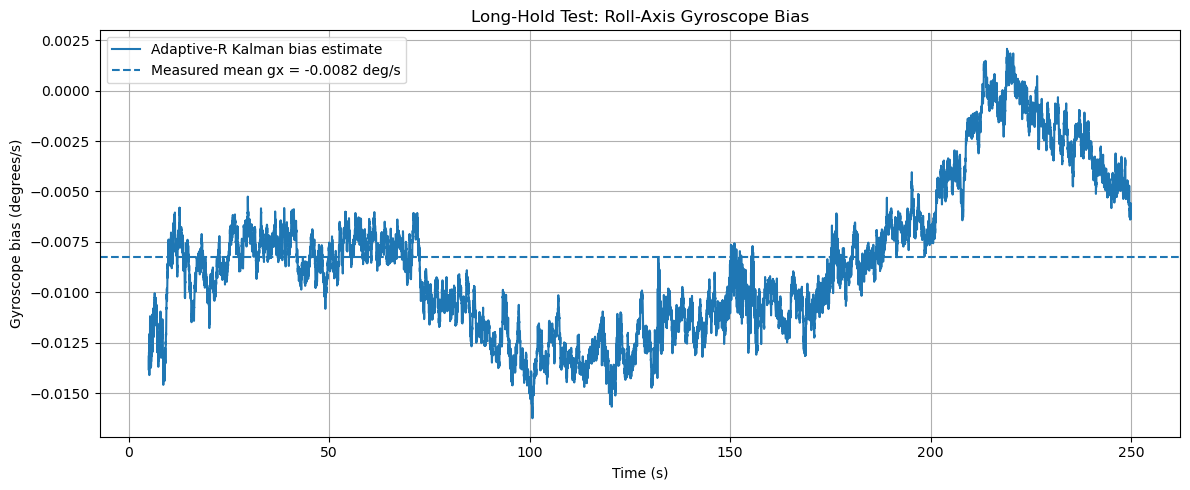

In [257]:
plt.figure(figsize=(12, 5))

plt.plot(
    bias_df["time_s"],
    bias_df["roll_bias_adaptive_dps"],
    label="Adaptive-R Kalman bias estimate"
)

plt.axhline(
    gx_mean_dps,
    linestyle="--",
    label=f"Measured mean gx = {gx_mean_dps:.4f} deg/s"
)

plt.xlabel("Time (s)")
plt.ylabel("Gyroscope bias (degrees/s)")
plt.title("Long-Hold Test: Roll-Axis Gyroscope Bias")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

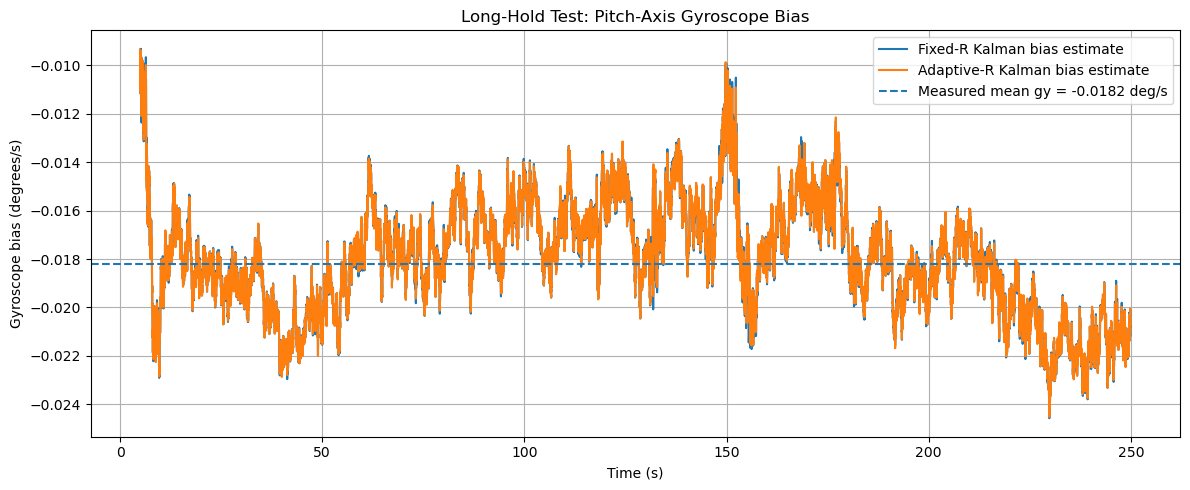

In [258]:
plt.figure(figsize=(12, 5))

plt.plot(
    bias_df["time_s"],
    bias_df["pitch_bias_fixed_dps"],
    label="Fixed-R Kalman bias estimate"
)

plt.plot(
    bias_df["time_s"],
    bias_df["pitch_bias_adaptive_dps"],
    label="Adaptive-R Kalman bias estimate"
)

plt.axhline(
    gy_mean_dps,
    linestyle="--",
    label=f"Measured mean gy = {gy_mean_dps:.4f} deg/s"
)

plt.xlabel("Time (s)")
plt.ylabel("Gyroscope bias (degrees/s)")
plt.title("Long-Hold Test: Pitch-Axis Gyroscope Bias")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Horizontal Shake Test: exposes the accelerometer weaknesses by applying a non gravitational acceleration

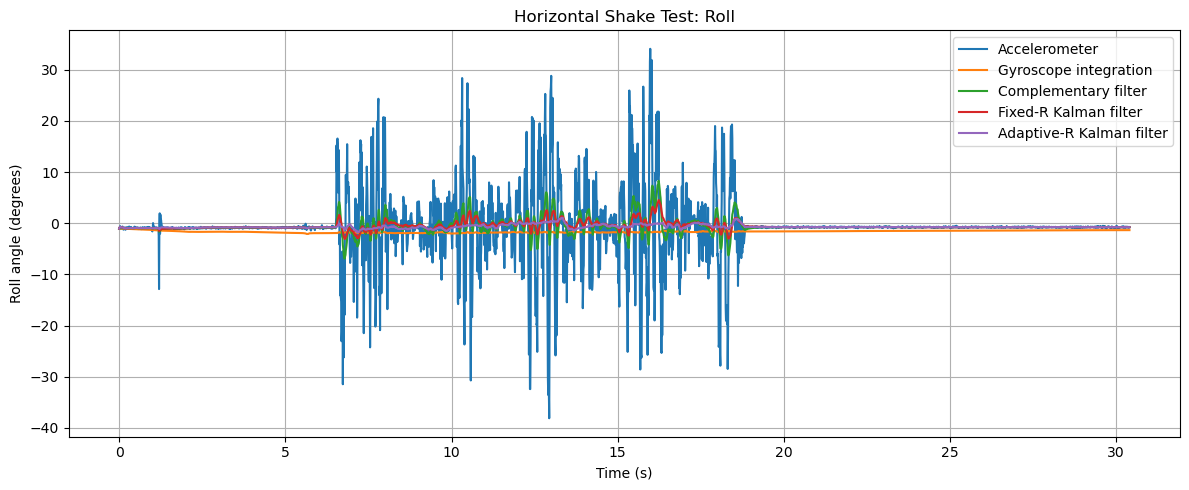

In [259]:
plt.figure(figsize=(12, 5))

plt.plot(
    shake_df["time_s"],
    shake_df["roll_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    shake_df["time_s"],
    shake_df["roll_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    shake_df["time_s"],
    shake_df["roll_comp_deg"],
    label="Complementary filter"
)

plt.plot(
    shake_df["time_s"],
    shake_df["roll_kf_fixed_deg"],
    label="Fixed-R Kalman filter"
)

plt.plot(
    shake_df["time_s"],
    shake_df["roll_kf_adaptive_deg"],
    label="Adaptive-R Kalman filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Roll angle (degrees)")
plt.title("Horizontal Shake Test: Roll")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

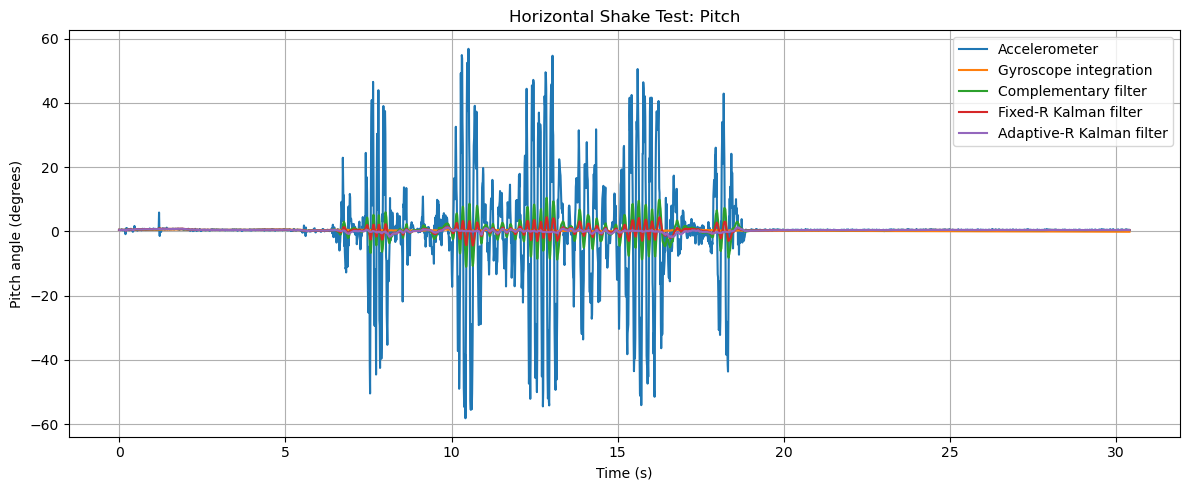

In [260]:
plt.figure(figsize=(12, 5))

plt.plot(
    shake_df["time_s"],
    shake_df["pitch_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    shake_df["time_s"],
    shake_df["pitch_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    shake_df["time_s"],
    shake_df["pitch_comp_deg"],
    label="Complementary filter"
)

plt.plot(
    shake_df["time_s"],
    shake_df["pitch_kf_fixed_deg"],
    label="Fixed-R Kalman filter"
)

plt.plot(
    shake_df["time_s"],
    shake_df["pitch_kf_adaptive_deg"],
    label="Adaptive-R Kalman filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Pitch angle (degrees)")
plt.title("Horizontal Shake Test: Pitch")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

/var/folders/xh/8c9sdj7124952trt8jvrjd440000gn/T/ipykernel_35936/4288064384.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


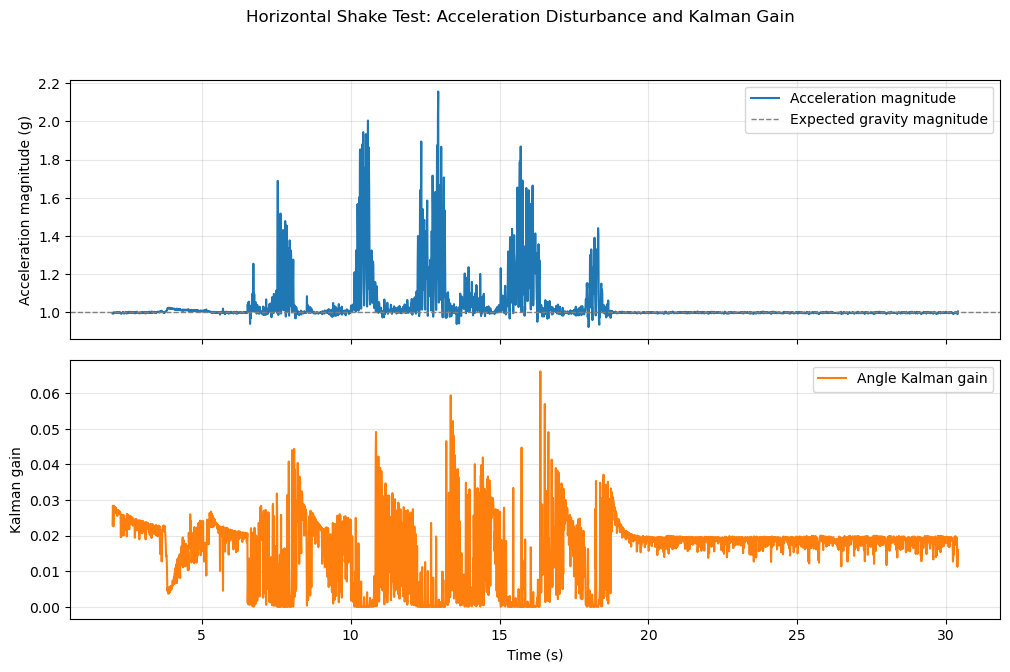

In [261]:
# Skip the Kalman filter initialization transient.
plot_df = shake_df.loc[
    shake_df["time_s"] >= 2.0
].copy()

fig, (ax_accel, ax_gain) = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={"hspace": 0.08}
)

# Top: acceleration magnitude
ax_accel.plot(
    plot_df["time_s"],
    plot_df["accel_mag_g"],
    color="tab:blue",
    linewidth=1.5,
    label="Acceleration magnitude"
)

ax_accel.axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    label="Expected gravity magnitude"
)

ax_accel.set_ylabel("Acceleration magnitude (g)")
ax_accel.legend(loc="upper right")
ax_accel.grid(alpha=0.3)

# Bottom: Kalman gain
ax_gain.plot(
    plot_df["time_s"],
    plot_df["roll_gain_kf"],
    color="tab:orange",
    linewidth=1.5,
    label="Angle Kalman gain"
)

ax_gain.set_xlabel("Time (s)")
ax_gain.set_ylabel("Kalman gain")
ax_gain.legend(loc="upper right")
ax_gain.grid(alpha=0.3)

fig.suptitle(
    "Horizontal Shake Test: "
    "Acceleration Disturbance and Kalman Gain"
)

fig.tight_layout()
plt.show()

Adaptive-Gain Tuning

In [262]:
gain_values = [
    10.0,
    100.0,
    1000.0,
    10000.0
]

shake_gain_results = {}

for gain in gain_values:
    shake_gain_results[gain] = process_imu_data(
        "Roll Pitch/Shake Data.csv",
        accel_rejection_gain=gain
    )

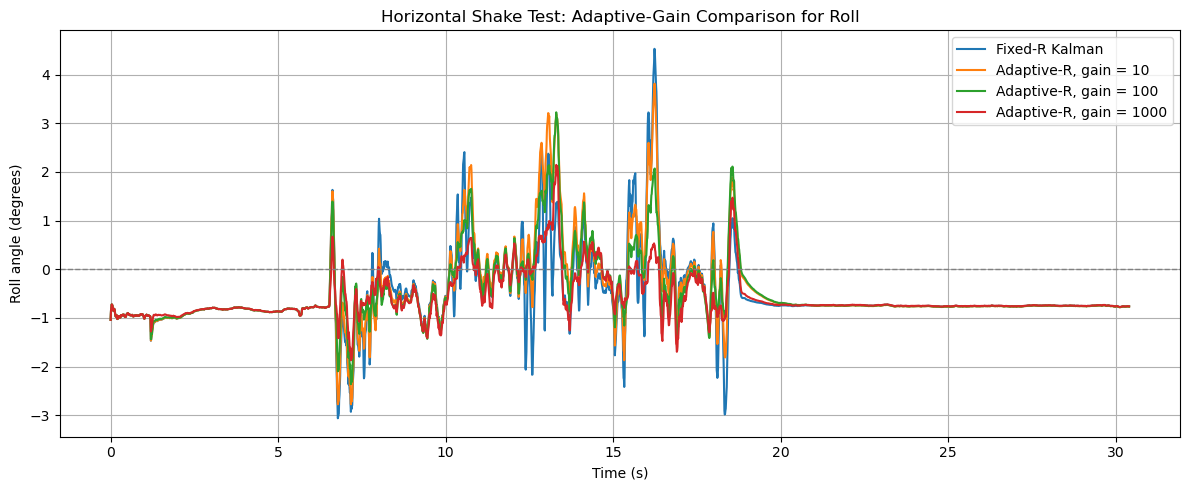

In [263]:
plt.figure(figsize=(12, 5))

# Fixed-R reference
plt.plot(
    shake_df["time_s"],
    shake_df["roll_kf_fixed_deg"],
    label="Fixed-R Kalman",
    linewidth=1.5
)

# Adaptive-R candidates
for gain, result_df in shake_gain_results.items():
    plt.plot(
        result_df["time_s"],
        result_df["roll_kf_adaptive_deg"],
        label=f"Adaptive-R, gain = {gain:g}",
        linewidth=1.5
    )

plt.axhline(
    0.0,
    color="gray",
    linestyle="--",
    linewidth=1.0
)

plt.xlabel("Time (s)")
plt.ylabel("Roll angle (degrees)")
plt.title("Horizontal Shake Test: Adaptive-Gain Comparison for Roll")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

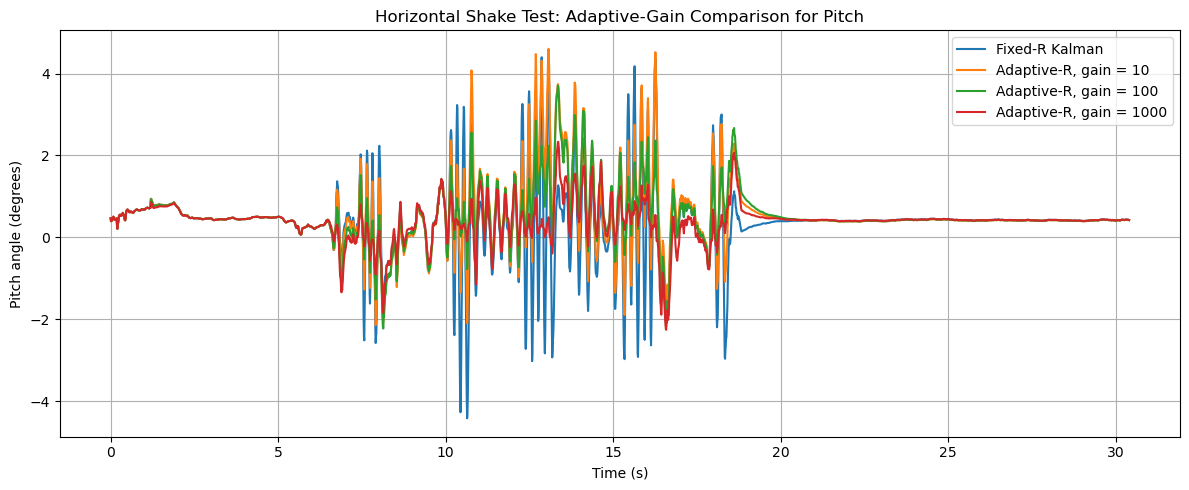

In [264]:
plt.figure(figsize=(12, 5))

plt.plot(
    shake_df["time_s"],
    shake_df["pitch_kf_fixed_deg"],
    label="Fixed-R Kalman",
    linewidth=1.5
)

for gain, result_df in shake_gain_results.items():
    plt.plot(
        result_df["time_s"],
        result_df["pitch_kf_adaptive_deg"],
        label=f"Adaptive-R, gain = {gain:g}",
        linewidth=1.5
    )

plt.xlabel("Time (s)")
plt.ylabel("Pitch angle (degrees)")
plt.title("Horizontal Shake Test: Adaptive-Gain Comparison for Pitch")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()